# PROJET ARENE

## Phase 1 : Charger et explorer

In [1]:
from sklearn.datasets import load_breast_cancer
import numpy as np

In [3]:
def explorer_dataset():
    """Charge le dataset et affiche ses caractéristiques de base.
    Doit afficher : nombre de lignes, nombre de colonnes,
    les classes possibles et leur répartition (équilibrée ou non ?).
    """
    # TODO : charger le dataset (return_X_y=True donne X et y séparés)
    data = load_breast_cancer()
    X, y = data.data, data.target

    # TODO : afficher la forme de X (combien de lignes, combien de colonnes)
    print(f"Lignes, colonnes : {X.shape}")

    # TODO : compter et afficher combien d'exemples dans chaque classe
    for i, nom in enumerate(data.target_names):
        count = np.sum(y == i)
        pct = count / len(y) * 100
        print(f"Classe {i} ({nom}) : {count} cas  ({pct:.1f}%)")

    return X, y

In [4]:
explorer_dataset()

Lignes, colonnes : (569, 30)
Classe 0 (malignant) : 212 cas  (37.3%)
Classe 1 (benign) : 357 cas  (62.7%)


(array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

## Phase 2 : Le pipeline supervisé complet


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [6]:
def entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test):
    """Entraîne le modèle, prédit sur le test, renvoie l'accuracy.
    Doit renvoyer un float entre 0 et 1.
    """
    # entraîner le modèle sur les données d'apprentissage
    modele.fit(X_train, y_train)

    # prédire sur le jeu de test
    y_pred = modele.predict(X_test)

    # calculer l'accuracy et la renvoyer
    return accuracy_score(y_test, y_pred)

In [7]:
# Charger et explorer
X, y = explorer_dataset()

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Tester avec un arbre de décision
modele = DecisionTreeClassifier(random_state=42)
acc = entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test)
print(f"Accuracy : {acc:.2%}")

Lignes, colonnes : (569, 30)
Classe 0 (malignant) : 212 cas  (37.3%)
Classe 1 (benign) : 357 cas  (62.7%)
Accuracy : 91.23%


## Phase 3 : L'Arène (premier classement)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [11]:
def arene(X_train, X_test, y_train, y_test):
    """Entraîne plusieurs modèles, renvoie un classement trié.
    Affiche un tableau lisible : nom de l'algo, accuracy.
    """
    # les algos qui s'affrontent
    modeles = {
        "Arbre de décision"     : DecisionTreeClassifier(random_state=42),
        "Régression logistique" : LogisticRegression(max_iter=200),
        "KNN"                   : KNeighborsClassifier(n_neighbors=3),
    }

    # évaluer chaque modèle sur le MÊME split
    resultats = {}
    for nom, modele in modeles.items():
        acc = entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test)
        resultats[nom] = acc

    # trier par accuracy décroissante et afficher le podium
    classement = sorted(resultats.items(), key=lambda x: x[1], reverse=True)
    print("=== ARÈNE DES ALGOS ===\n")
    for rang, (nom, acc) in enumerate(classement, start=1):
        print(f"{rang}. {nom:<30} : {acc:.2%}")

    return classement

In [12]:
classement = arene(X_train, X_test, y_train, y_test)

=== ARÈNE DES ALGOS ===

1. Régression logistique          : 95.61%
2. KNN                            : 92.98%
3. Arbre de décision              : 91.23%


c:\Users\amosc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Phase 4 : Bascule non-supervisé

In [13]:
from sklearn.cluster import KMeans

In [14]:
def clustering_aveugle(X):
    """Regroupe les données en 2 clusters sans les étiquettes.
    Renvoie les labels de cluster attribués à chaque point.
    """
    # fit_predict fait l'entraînement ET la prédiction d'un coup
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    return labels

In [15]:
# lancer le clustering sur X complet (sans y !)
labels_kmeans = clustering_aveugle(X)

# comparer avec les vraies classes
print("=== COMPARAISON CLUSTERS vs VRAIES CLASSES ===\n")
print(f"{'':30} | Malignant (0) | Benign (1)")
print("-" * 55)

for cluster in [0, 1]:
    masque = labels_kmeans == cluster
    nb_malin  = np.sum(y[masque] == 0)
    nb_benin  = np.sum(y[masque] == 1)
    total     = np.sum(masque)
    print(f"Cluster {cluster} ({total} points){'':<14} | {nb_malin:<14} | {nb_benin}")

print()
# correspondance globale
# KMeans peut inverser les labels (0↔1),
acc_direct  = np.mean(labels_kmeans == y)
acc_inverse = np.mean(labels_kmeans != y)
acc_kmeans  = max(acc_direct, acc_inverse)
print(f"Correspondance avec les vraies classes : {acc_kmeans:.2%}")

=== COMPARAISON CLUSTERS vs VRAIES CLASSES ===

                               | Malignant (0) | Benign (1)
-------------------------------------------------------
Cluster 0 (131 points)               | 130            | 1
Cluster 1 (438 points)               | 82             | 356

Correspondance avec les vraies classes : 85.41%


c:\Users\amosc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


## Phase 5 : Changer de terrain

In [16]:
from sklearn.datasets import load_wine

In [18]:
#  explorer_dataset() mais adaptée pour wine
def explorer_dataset_wine():
    """Même logique que explorer_dataset() mais pour load_wine."""
    data = load_wine()
    X, y = data.data, data.target

    print(f"Lignes, colonnes : {X.shape}")
    print()

    for i, nom in enumerate(data.target_names):
        count = np.sum(y == i)
        pct = count / len(y) * 100
        print(f"Classe {i} ({nom}) : {count} cas  ({pct:.1f}%)")

    return X, y

In [19]:
print("=== DATASET WINE ===\n")
X_wine, y_wine = explorer_dataset_wine()

# nouveau split sur wine
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

# même fonction arene()
print("\n")
classement_wine = arene(X_train_w, X_test_w, y_train_w, y_test_w)

=== DATASET WINE ===

Lignes, colonnes : (178, 13)

Classe 0 (class_0) : 59 cas  (33.1%)
Classe 1 (class_1) : 71 cas  (39.9%)
Classe 2 (class_2) : 48 cas  (27.0%)


=== ARÈNE DES ALGOS ===

1. Régression logistique          : 97.22%
2. Arbre de décision              : 94.44%
3. KNN                            : 75.00%


c:\Users\amosc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Phase 6 : Voir pour comprendre

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [21]:
def graphique_arene(classement, titre="Arène des Algos"):
    """Trace un diagramme en barres des accuracies."""
    noms  = [c[0] for c in classement]
    accs  = [c[1] * 100 for c in classement]
    couleurs = ["#1D9E75", "#378ADD", "#E24B4A"]

    plt.figure(figsize=(8, 4))
    barres = plt.barh(noms, accs, color=couleurs[:len(noms)])
    plt.xlabel("Accuracy (%)")
    plt.title(titre)
    plt.xlim(80, 100)

    # afficher la valeur sur chaque barre
    for barre, acc in zip(barres, accs):
        plt.text(
            barre.get_width() - 0.5,
            barre.get_y() + barre.get_height() / 2,
            f"{acc:.2f}%",
            va="center", ha="right",
            color="white", fontweight="bold"
        )

    plt.tight_layout()
    plt.show()

In [22]:
def matrice_confusion(modele, X_train, X_test, y_train, y_test, noms_classes):
    """Affiche la matrice de confusion du modèle champion."""
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=noms_classes
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title("Matrice de confusion — champion")
    plt.tight_layout()
    plt.show()

    # afficher ce que ça veut dire
    print(f"\nVraies prédictions (diagonale) : {cm.diagonal().sum()}")
    print(f"Erreurs totales                : {cm.sum() - cm.diagonal().sum()}")

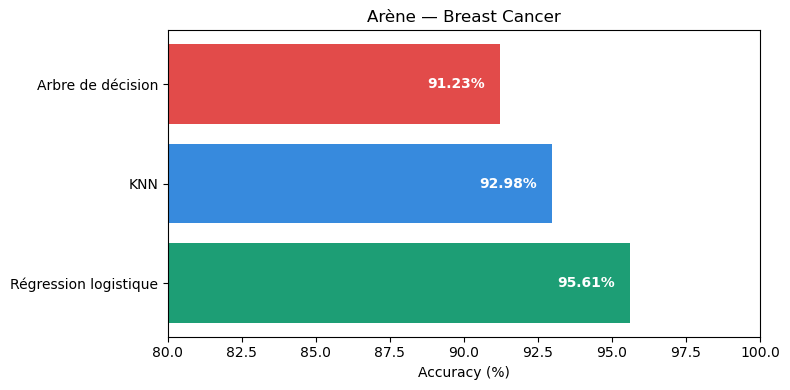

c:\Users\amosc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


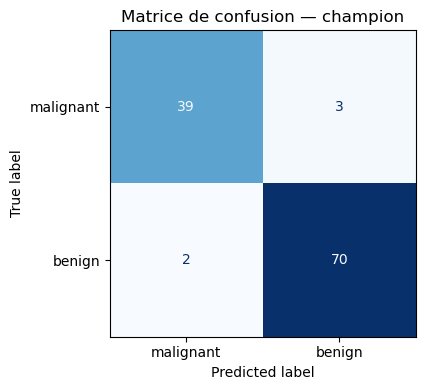


Vraies prédictions (diagonale) : 109
Erreurs totales                : 5


In [23]:
# graphique sur breast cancer
graphique_arene(classement, titre="Arène — Breast Cancer")

# champion = premier du classement
nom_champion = classement[0][0]
modeles_dispo = {
    "Arbre de décision"     : DecisionTreeClassifier(random_state=42),
    "Régression logistique" : LogisticRegression(max_iter=200),
    "KNN"                   : KNeighborsClassifier(n_neighbors=3),
}
champion = modeles_dispo[nom_champion]

# matrice de confusion du champion sur breast cancer
data_bc = load_breast_cancer()
matrice_confusion(
    champion,
    X_train, X_test,
    y_train, y_test,
    noms_classes=data_bc.target_names
)

## Phase 7 : Le buff scaling (et la triche qui se retourne contre vous)

## Phase 8 : Raconter votre Arène